# Phase 1: Implementation and Comparison of Classical Matching Mechanisms

**Authors:** Sébastien Rivière, Gwendal Déléage, Gabriel Viterbo, Rafael Sesoko

## 1. Introduction

**Context & Objectives:** Overview of the matching problem focused on assigning students to projects based on ordinal preference lists to produce a satisfactory and fair allocation. The study aims to implement and compare classical algorithms on the same dataset and explore advanced extensions.

**Algorithmic Overview:** High-level presentation of the three implemented classical mechanisms:
* Gale-Shapley (GS): Applicant-proposing and project-proposing stable baseline variants.
* Serial Dictatorship (SD): Multi-variant execution (random order, priority-based order).
* Top Trading Cycles (TTC): Core execution with explicit cycle detection.

**Data Sources:** Parallel tracking utilizing anonymized real preference lists from the latest DSAI Project matching alongside controlled synthetic preference models.

---

## 2. Notebook Configuration and Initialization

This section configures the environment and imports the necessary modules. All the algorithms and evaluation functions called here have been previously implemented and verified in the project's source files.

### 2.1. Imports

In [49]:
# External imports
import pandas as pd

# Local imports
from data import load_real_instance, create_synthetic_instance
from mechanisms import gale_shapley, serial_dictatorship, ttc_from_stable, ttc_from_matching
from metrics import rank_sum_cost, borda_welfare_cost, top_n_assigned_cost, square_rank_sum_cost, nash_welfare_cost, max_rank_cost, unassigned_students_cost
from metrics import blocking_pairs_stability_score, justified_envy_stability_score, wasteful_capacity_stability_score
from visualisation import plot_rank_distribution, plot_project_occupancy

### 2.2. Configuration

In [50]:
# Panda
pd.options.display.float_format = '{:.3f}'.format

# Real data
real_data_csv_path = "../data/projects-dsai-2026-anon.csv"
real_data_project_capacity = 5

---

## 3. Pipeline Definition and Components

This section charts the end-to-end data flow, from raw data ingestion/generation to structured output tables.

### 3.1. Matching computation

In [51]:
algorithms = {
    "gale_shapley": gale_shapley,
    "serial_dictatorship": serial_dictatorship,
    "top_trading_cycles": lambda instance: ttc_from_matching(gale_shapley(instance))
}

In [52]:
def compute_matching(instance):
    return {
        algorithm_name: algorithm(instance)
        for algorithm_name, algorithm in algorithms.items()
    }

### 3.2. Cost and stability computations

In [53]:
cost_functions = {
    "rank_sum_cost": rank_sum_cost,
    "borda_welfare_cost": borda_welfare_cost,
    "top_3_assigned_cost": lambda matching: top_n_assigned_cost(matching, n=3),
    "square_rank_sum_cost": square_rank_sum_cost,
    "nash_welfare_cost": nash_welfare_cost,
    "max_rank_cost": max_rank_cost,
    "unassigned_students_cost": unassigned_students_cost
}

In [54]:
stability_functions = {
    "blocking_pairs_stability_score": blocking_pairs_stability_score,
    "justified_envy_stability_score": justified_envy_stability_score,
    "wasteful_capacity_stability_score": wasteful_capacity_stability_score
}

In [55]:
def compute_cost(matchings):
    return pd.DataFrame.from_dict({
        alg_name: {
            cost_name: cost_fn(matching)
            for cost_name, cost_fn in cost_functions.items()
        }
        for alg_name, matching in matchings.items()
    }, orient="index")

In [56]:
def compute_stability(matchings):
    return pd.DataFrame.from_dict({
        alg_name: {
            stability_name: stability_fn(matching)
            for stability_name, stability_fn in stability_functions.items()
        }
        for alg_name, matching in matchings.items()
    }, orient="index")

In [57]:
def compute_cost_stability(matchings):
    cost_df = compute_cost(matchings)
    stability_df = compute_stability(matchings)
    return pd.concat([cost_df, stability_df], axis=1)

---

## 4. Analysis

**TEMPORARY NOTE** : The TODOs below are only indications, feel free to add or change things.

### 4.1. Real data analysis

TODO : Evaluate the algorithms using the real-world dataset. Measure and compare the global cost (efficiency) and the total number of blocking pairs (stability) for each mechanism. Make visualisation for example for the rank distribution of the assignements, to visualise the number of students per projet considering their capacity, unassigned students etc.

In [58]:
instance_real = load_real_instance(real_data_csv_path, real_data_project_capacity)
matching_real = compute_matching(instance_real)
cost_real = compute_cost(matching_real)
stability_real = compute_stability(matching_real)

In [59]:
cost_real

,rank_sum_cost,borda_welfare_cost,top_3_assigned_cost,square_rank_sum_cost,nash_welfare_cost,max_rank_cost,unassigned_students_cost
gale_shapley,0.144,0.144,0.349,0.064,0.061,1.000,0.009
serial_dictatorship,0.144,0.144,0.349,0.064,0.061,1.000,0.009
top_trading_cycles,0.144,0.144,0.349,0.064,0.061,1.000,0.009


In [60]:
stability_real

,blocking_pairs_stability_score,justified_envy_stability_score,wasteful_capacity_stability_score
gale_shapley,0.000,0.000,0.000
serial_dictatorship,0.000,0.000,0.000
top_trading_cycles,0.000,0.000,0.000


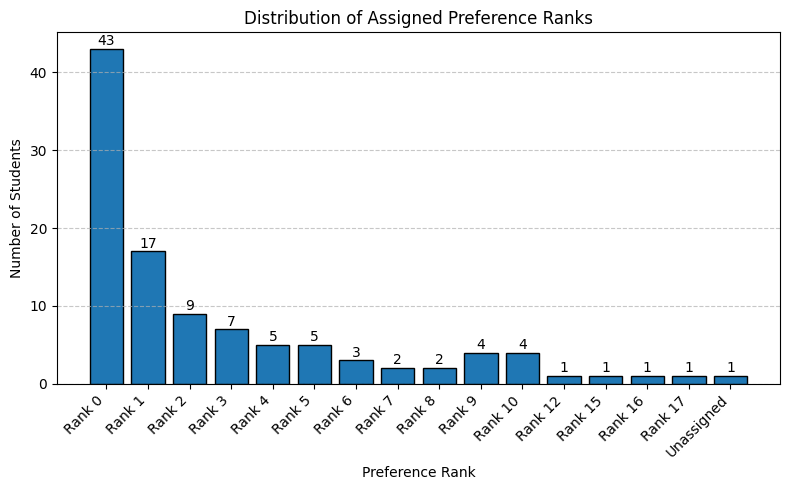

In [65]:
plot_rank_distribution(matching_real["gale_shapley"])

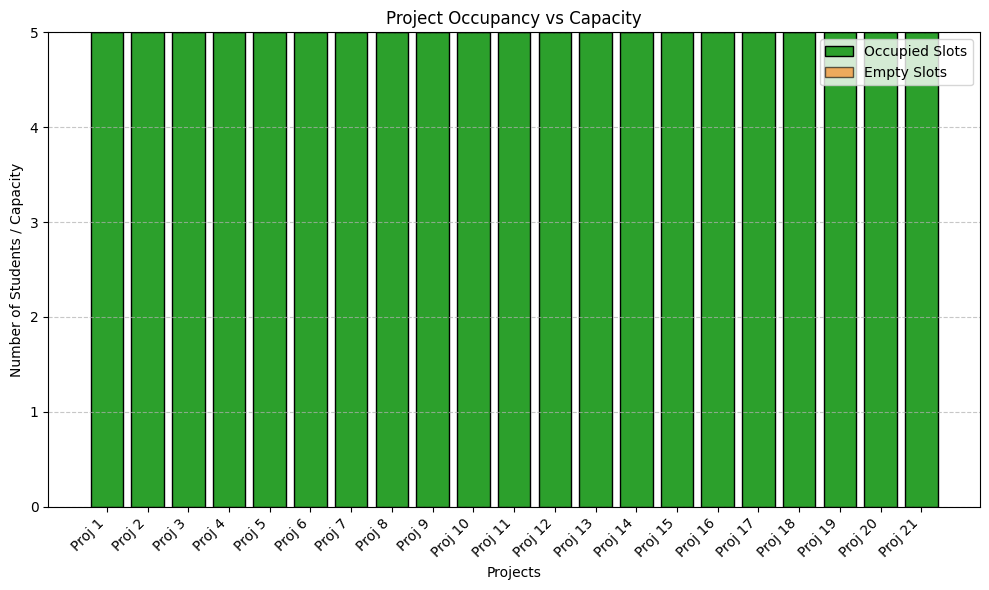

In [62]:
plot_project_occupancy(matching_real["gale_shapley"])

### 4.2. Synthetic data analysis

#### 4.2.1. Impact of Preference Homogeneity

TODO : Run simulations varying $\phi$ from 0 to 1. Measure the average cost and the number of blocking pairs for SD and TTC (especially near $\phi = 0$). Plot the results on a line graph ($\phi$ on X-axis, metrics on Y-axis).

#### 4.2.2. Scalability

TODO : Increase $N$ (students) and $M$ (projects) while keeping the capacity ratio constant. Record the empirical execution time and analyze algorithm behavior under high resource scarcity.

### 4.3. Efficiency VS Stability trade-off analysis

TODO : Generate a 2D scatter plot to map the Pareto frontier. Plot the Global Cost Score on the X-axis (Efficiency) against the Number of Blocking Pairs on the Y-axis (Instability). Use distinct markers for each algorithm to identify the best compromise.

---

## 5. Synthesis and Perspectives

### 5.1. Performance Summary

TODO

### 5.2. Transition to Phase 2

TODO